In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('loan_approved.csv')

In [3]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# Basic checks

In [4]:
data.shape

(614, 13)

In [5]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [9]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [10]:
cat_cols = data.select_dtypes(include='object')
cat_cols

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y


In [11]:
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0
610,4106,0.0,40.0,180.0,1.0
611,8072,240.0,253.0,360.0,1.0
612,7583,0.0,187.0,360.0,1.0


In [12]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [13]:
# find all unique values
for x in cat_cols.drop(columns='Loan_ID'):
  print(x,'-->',data[x].unique())

Gender --> ['Male' 'Female' nan]
Married --> ['No' 'Yes' nan]
Dependents --> ['0' '1' '2' '3+' nan]
Education --> ['Graduate' 'Not Graduate']
Self_Employed --> ['No' 'Yes' nan]
Property_Area --> ['Urban' 'Rural' 'Semiurban']
Loan_Status (Approved) --> ['Y' 'N']


In [14]:
# find all value counts
for x in cat_cols.drop(columns='Loan_ID'):
  print(data[x].value_counts())
  print()

Gender
Male      489
Female    112
Name: count, dtype: int64

Married
Yes    398
No     213
Name: count, dtype: int64

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Loan_Status (Approved)
Y    422
N    192
Name: count, dtype: int64



**Handle Missing values**

In [15]:
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


- Gender , Married ,Dependents,Self_Employed,LoanAmount , Loan_Amount_Term , Credit_History

**Gender**

In [16]:
data.loc[:,'Gender'].dtypes

dtype('O')

In [17]:
data.loc[:,'Gender'].mode()[0]

'Male'

In [18]:
data.loc[:,'Gender']=data.loc[:,'Gender'].fillna(data.loc[:,'Gender'].mode()[0])

**Married**

In [19]:
data.loc[:,'Married'].dtypes

dtype('O')

In [20]:
data.loc[:,'Married'].mode()[0]

'Yes'

In [21]:
data.loc[:,'Married']=data.loc[:,'Married'].fillna(data.loc[:,'Married'].mode()[0])

**Self_Employed**

In [22]:
data.loc[:,'Self_Employed'].dtypes

dtype('O')

In [23]:
data.loc[:,'Self_Employed'].mode()[0]

'No'

In [24]:
data.loc[:,'Self_Employed']=data.loc[:,'Self_Employed'].fillna(data.loc[:,'Self_Employed'].mode()[0])

**Dependents**

In [25]:
data.loc[:,'Dependents'].dtypes

dtype('O')

In [26]:
data.loc[:,'Dependents'].mode()[0]

'0'

In [27]:
data.loc[:,'Dependents']=data.loc[:,'Dependents'].fillna(data.loc[:,'Dependents'].mode()[0])

**Credit_History**

In [28]:
data.loc[:,'Credit_History'].unique()

array([ 1.,  0., nan])

In [29]:
data.loc[:,'Credit_History'].mode()[0]

np.float64(1.0)

In [30]:
data.loc[:,'Credit_History'] = data.loc[:,'Credit_History'].fillna(data.loc[:,'Credit_History'].mode()[0])

**LoanAmount**

In [31]:
data.loc[:,'LoanAmount'].dtypes

dtype('float64')

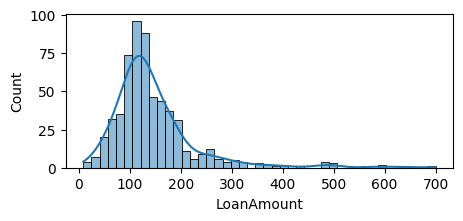

In [32]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='LoanAmount',kde=True)
plt.show()

In [33]:
data.loc[:,'LoanAmount'].skew()

np.float64(2.677551679256059)

In [34]:
data.loc[:,'LoanAmount'].median()

128.0

In [35]:
data.loc[:,'LoanAmount']=data.loc[:,'LoanAmount'].fillna(data.loc[:,'LoanAmount'].median())

**Loan_Amount_Term**

In [36]:
data.loc[:,'Loan_Amount_Term'].dtype

dtype('float64')

In [37]:
data.loc[:,'Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

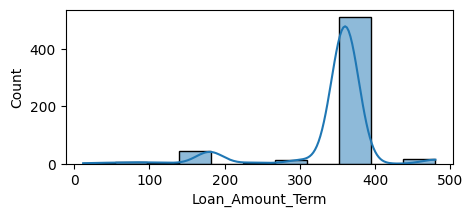

In [38]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='Loan_Amount_Term',kde=True)
plt.show()


In [39]:
data.loc[:,'Loan_Amount_Term'].skew()

np.float64(-2.362414124216269)

In [40]:
data.loc[:,'Loan_Amount_Term'].median()

360.0

In [41]:
data.loc[:,'Loan_Amount_Term']=data.loc[:,'Loan_Amount_Term'].fillna(data.loc[:,'Loan_Amount_Term'].median())

In [42]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


**Handling Outliers**

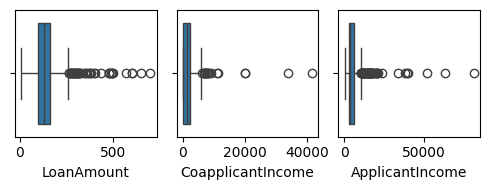

In [43]:
# CoapplicantIncome	LoanAmount ApplicantIncome
fig,ax = plt.subplots(1,3,figsize=(5,2))
sns.boxplot(data,x='LoanAmount',ax=ax[0])
sns.boxplot(data,x='CoapplicantIncome',ax=ax[1])
sns.boxplot(data,x='ApplicantIncome',ax=ax[2])
plt.tight_layout()

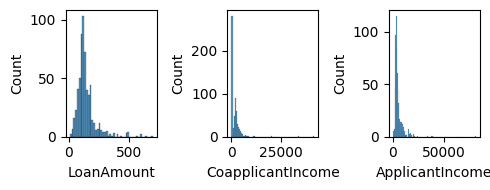

In [44]:
fig,ax = plt.subplots(1,3,figsize=(5,2))
sns.histplot(data,x='LoanAmount',ax=ax[0])
sns.histplot(data,x='CoapplicantIncome',ax=ax[1])
sns.histplot(data,x='ApplicantIncome',ax=ax[2])
plt.tight_layout()

In [45]:
A =['CoapplicantIncome',	'LoanAmount', 'ApplicantIncome']
for x in A:
  print(data[x].skew())

7.491531216657306
2.743052748820892
6.539513113994625


**CoapplicantIncome**

In [46]:
Q1 = data.loc[:,'CoapplicantIncome'].quantile(0.25)
Q3 = data.loc[:,'CoapplicantIncome'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR

In [47]:
data[(data.loc[:,'CoapplicantIncome']<lower_limit)|(data.loc[:,'CoapplicantIncome']>upper_limit)]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N
12,LP001028,Male,Yes,2,Graduate,No,3073,8106.0,200.0,360.0,1.0,Urban,Y
38,LP001114,Male,No,0,Graduate,No,4166,7210.0,184.0,360.0,1.0,Urban,Y
122,LP001431,Female,No,0,Graduate,No,2137,8980.0,137.0,360.0,0.0,Semiurban,Y
135,LP001488,Male,Yes,3+,Graduate,No,4000,7750.0,290.0,360.0,1.0,Semiurban,N
177,LP001610,Male,Yes,3+,Graduate,No,5516,11300.0,495.0,360.0,0.0,Semiurban,N
180,LP001633,Male,Yes,1,Graduate,No,6400,7250.0,180.0,360.0,0.0,Urban,N
253,LP001843,Male,Yes,1,Not Graduate,No,2661,7101.0,279.0,180.0,1.0,Semiurban,Y
349,LP002138,Male,Yes,0,Graduate,No,2625,6250.0,187.0,360.0,1.0,Rural,Y
372,LP002201,Male,Yes,2,Graduate,Yes,9323,7873.0,380.0,300.0,1.0,Rural,Y


In [48]:
len(data[(data.loc[:,'CoapplicantIncome']<lower_limit)|(data.loc[:,'CoapplicantIncome']>upper_limit)])/len(data)*100

2.9315960912052117

In [49]:
data.loc[(data.loc[:,'CoapplicantIncome']<lower_limit)|(data.loc[:,'CoapplicantIncome']>upper_limit),
         'CoapplicantIncome']=data.loc[:,'CoapplicantIncome'].median()

**ApplicantIncome**

In [50]:
Q1 = data.loc[:,'ApplicantIncome'].quantile(0.25)
Q3 = data.loc[:,'ApplicantIncome'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR

In [51]:
data[(data.loc[:,'ApplicantIncome']<lower_limit)|(data.loc[:,'ApplicantIncome']>upper_limit)]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
9,LP001020,Male,Yes,1,Graduate,No,12841,1188.5,349.0,360.0,1.0,Semiurban,N
34,LP001100,Male,No,3+,Graduate,No,12500,3000.0,320.0,360.0,1.0,Rural,N
54,LP001186,Female,Yes,1,Graduate,Yes,11500,0.0,286.0,360.0,0.0,Urban,N
67,LP001233,Male,Yes,1,Graduate,No,10750,0.0,312.0,360.0,1.0,Urban,Y
102,LP001350,Male,Yes,0,Graduate,No,13650,0.0,128.0,360.0,1.0,Urban,Y
106,LP001369,Male,Yes,2,Graduate,No,11417,1126.0,225.0,360.0,1.0,Urban,Y
115,LP001401,Male,Yes,1,Graduate,No,14583,0.0,185.0,180.0,1.0,Rural,Y
119,LP001422,Female,No,0,Graduate,No,10408,0.0,259.0,360.0,1.0,Urban,Y
126,LP001448,Male,Yes,3+,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y
128,LP001451,Male,Yes,1,Graduate,Yes,10513,3850.0,160.0,180.0,0.0,Urban,N


In [52]:
len(data[(data.loc[:,'ApplicantIncome']<lower_limit)|(data.loc[:,'ApplicantIncome']>upper_limit)])/len(data)*100

8.143322475570033

**LoanAmount**

In [53]:
Q1 = data.loc[:,'LoanAmount'].quantile(0.25)
Q3 = data.loc[:,'LoanAmount'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR

In [54]:
data[(data.loc[:,'LoanAmount']<lower_limit)|(data.loc[:,'LoanAmount']>upper_limit)]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,1188.5,349.0,360.0,1.0,Semiurban,N
21,LP001046,Male,Yes,1,Graduate,No,5955,5625.0,315.0,360.0,1.0,Urban,Y
34,LP001100,Male,No,3+,Graduate,No,12500,3000.0,320.0,360.0,1.0,Rural,N
54,LP001186,Female,Yes,1,Graduate,Yes,11500,0.0,286.0,360.0,0.0,Urban,N
67,LP001233,Male,Yes,1,Graduate,No,10750,0.0,312.0,360.0,1.0,Urban,Y
83,LP001273,Male,Yes,0,Graduate,No,6000,2250.0,265.0,360.0,1.0,Semiurban,N
126,LP001448,Male,Yes,3+,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y
130,LP001469,Male,No,0,Graduate,Yes,20166,0.0,650.0,480.0,1.0,Urban,Y
135,LP001488,Male,Yes,3+,Graduate,No,4000,1188.5,290.0,360.0,1.0,Semiurban,N


In [55]:
len(data[(data.loc[:,'LoanAmount']<lower_limit)|(data.loc[:,'LoanAmount']>upper_limit)])/len(data)*100

6.677524429967427

# **Encoding**

In [56]:
# Gender : One hot encoding
# Married : label encoder
# Education	 : Target encoding
# Self_Employed : Label encoder
# Property_Area :Target encoding
#Loan_Status (Approved) : Label encoder
# Dependents : replace 3+ with 3

In [57]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'married']=le.fit_transform(data.loc[:,'Married'])
data.loc[:,'self_Employed']=le.fit_transform(data.loc[:,'Self_Employed'])
data.loc[:,'loan_status']=le.fit_transform(data.loc[:,'Loan_Status (Approved)'])

In [58]:
data.drop(columns=['Married','Self_Employed','Loan_Status (Approved)'],inplace=True)

In [59]:
data = pd.get_dummies(data,columns=['Gender'],dtype='int')
data

,Loan_ID,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,married,self_Employed,loan_status,Gender_Female,Gender_Male
0,LP001002,0,Graduate,5849,0.0,128.0,360.0,1.0,Urban,0,0,1,0,1
1,LP001003,1,Graduate,4583,1508.0,128.0,360.0,1.0,Rural,1,0,0,0,1
2,LP001005,0,Graduate,3000,0.0,66.0,360.0,1.0,Urban,1,1,1,0,1
3,LP001006,0,Not Graduate,2583,2358.0,120.0,360.0,1.0,Urban,1,0,1,0,1
4,LP001008,0,Graduate,6000,0.0,141.0,360.0,1.0,Urban,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,Graduate,2900,0.0,71.0,360.0,1.0,Rural,0,0,1,1,0
610,LP002979,3+,Graduate,4106,0.0,40.0,180.0,1.0,Rural,1,0,1,0,1
611,LP002983,1,Graduate,8072,240.0,253.0,360.0,1.0,Urban,1,0,1,0,1
612,LP002984,2,Graduate,7583,0.0,187.0,360.0,1.0,Urban,1,0,1,0,1


In [60]:
data.loc[:,'education'] = data.loc[:,'Education'].map({'Graduate':1,'Not Graduate':0})

<Axes: xlabel='Property_Area', ylabel='count'>

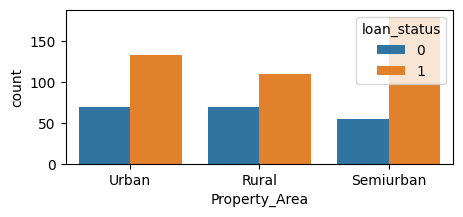

In [61]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='Property_Area',hue='loan_status')

In [62]:
data.loc[:,'property_Area']=data.loc[:,'Property_Area'].map({'Semiurban':2,'Urban':1,'Rural':0})

In [63]:
data.drop(columns=['Education','Property_Area'],inplace=True)

In [64]:
# replace 3+ with 3
data.loc[:,'Dependents']= data.loc[:,'Dependents'].replace({'3+':3})

In [65]:
data.loc[:,'dependents'] = data.loc[:,'Dependents'].astype('int64')

In [66]:
data.loc[:,'dependents']

,dependents
0,0
1,1
2,0
3,0
4,0
...,...
609,0
610,3
611,1
612,2


In [67]:
data.drop(columns='Dependents',inplace=True)

# Apply Scaling

In [68]:
# ApplicantIncome	CoapplicantIncome	LoanAmount	Loan_Amount_Term
from sklearn.preprocessing import StandardScaler
model = StandardScaler()
data[['ApplicantIncome']]= model.fit_transform(data[['ApplicantIncome']])
data[['CoapplicantIncome']]= model.fit_transform(data[['CoapplicantIncome']])
data[['LoanAmount']]= model.fit_transform(data[['LoanAmount']])
data[['Loan_Amount_Term']]= model.fit_transform(data[['Loan_Amount_Term']])

In [69]:
data.drop(columns='Loan_ID',inplace=True)

# SPlit data

In [70]:
x = data.drop(columns='loan_status')
y = data.loc[:,'loan_status']

# Split data for training and testing

In [71]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Smote

<Axes: xlabel='loan_status', ylabel='count'>

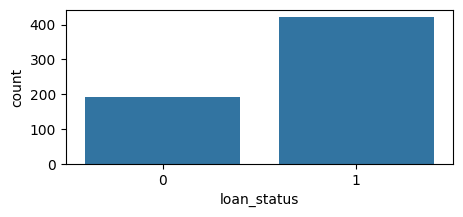

In [72]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='loan_status')

In [73]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE()
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)


In [77]:
Counter(y_train) # before balancing

Counter({0: 149, 1: 342})

In [78]:
Counter(y_sampled)#after balancing

Counter({0: 342, 1: 342})

# MLP Classifier

In [79]:
# MLP : Multi layer perceptron
from sklearn.neural_network import MLPClassifier
model = MLPClassifier()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [80]:
# evaluate the model
from sklearn.metrics import confusion_matrix , accuracy_score,recall_score,precision_score,f1_score

In [81]:
confusion_matrix(y_test,y_pred)

array([[22, 21],
       [12, 68]])

In [82]:
accuracy_score(y_test,y_pred)

0.7317073170731707

In [83]:
precision_score(y_test,y_pred)

0.7640449438202247

In [84]:
recall_score(y_test,y_pred)

0.85

In [85]:
f1_score(y_test,y_pred)

0.8047337278106509

# With Hyperparameters

In [94]:
# MLP : Multi layer perceptron
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(20,20),activation='relu',solver='adam',random_state=42)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [95]:
confusion_matrix(y_test,y_pred)

array([[21, 22],
       [11, 69]])

In [96]:
accuracy_score(y_test,y_pred)

0.7317073170731707

In [97]:
precision_score(y_test,y_pred)

0.7582417582417582

In [98]:
recall_score(y_test,y_pred)

0.8625

In [99]:
f1_score(y_test,y_pred)

0.8070175438596491